# 02 — Prétraitement & Feature Engineering
## Projet EDF — Prédiction de la Consommation Électrique

**Objectif :** Préparer le dataset final (nettoyage, feature engineering, normalisation, split train/test) prêt pour l'entraînement des 4 modèles ML.

**Étapes :**
1. Chargement et nettoyage des données
2. Feature engineering (lag features, encodage cyclique, OHE)
3. Split temporel train / test (80% / 20%)
4. Normalisation StandardScaler
5. Visualisation des features finales

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from data_pipeline.ingestion import generate_synthetic_data
from data_pipeline.preprocessing import (
    clean_data, build_features, get_feature_columns,
    split_train_test, normalize_features
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110})

PROCESSED_PATH = Path('../data/processed')
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
print(' Imports OK')

✅ Imports OK


## 1. Chargement et nettoyage

In [2]:
# Chargement
df_raw = generate_synthetic_data('2019-01-01', '2024-12-31')
print(f'Dataset brut : {df_raw.shape}')

# Nettoyage
df_clean = clean_data(df_raw)
print(f'Dataset nettoyé : {df_clean.shape}')
print(f'Valeurs nulles restantes : {df_clean.isnull().sum().sum()}')

Dataset brut : (2192, 9)
Dataset nettoyé : (2192, 9)
Valeurs nulles restantes : 0


## 2. Feature Engineering

In [3]:
df_feat = build_features(df_clean)

print('=== Colonnes après feature engineering ===')
for col in df_feat.columns:
    print(f'  {col:<25} — {df_feat[col].dtype}   moy={df_feat[col].mean():.2f}')

print(f'\nShape finale : {df_feat.shape}')

=== Colonnes après feature engineering ===
  date                      — datetime64[ns]   moy=.2f
  consommation_mw           — float64   moy=65691.39
  temperature_moyenne       — float64   moy=12.09
  temperature_min           — float64   moy=9.12
  temperature_max           — float64   moy=16.10
  type_jour                 — int32   moy=0.32
  mois                      — int32   moy=6.54
  jour_semaine              — int32   moy=3.00
  jour_annee                — int32   moy=183.74
  consommation_j1           — float64   moy=65688.84
  consommation_j7           — float64   moy=65687.65
  consommation_j14          — float64   moy=65598.09
  consommation_ma7          — float64   moy=65687.14
  mois_sin                  — float64   moy=-0.01
  mois_cos                  — float64   moy=-0.00
  jour_sin                  — float64   moy=0.00
  jour_cos                  — float64   moy=0.00
  est_ouvre                 — int32   moy=0.70
  est_weekend               — int32   moy=0.28
  est_

In [4]:
# Vérification des lag features
print('Aperçu des lag features (5 premières lignes) :')
df_feat[['date', 'consommation_mw', 'consommation_j1', 'consommation_j7', 'consommation_ma7']].head()

Aperçu des lag features (5 premières lignes) :


,date,consommation_mw,consommation_j1,consommation_j7,consommation_ma7
0,2019-01-08,95799.0,90759.0,91624.0,94110.142857
1,2019-01-09,100000.0,95799.0,98228.0,94706.571429
2,2019-01-10,96505.0,100000.0,95669.0,94959.714286
3,2019-01-11,100000.0,96505.0,90730.0,95079.142857
4,2019-01-12,96247.0,100000.0,95994.0,96403.428571


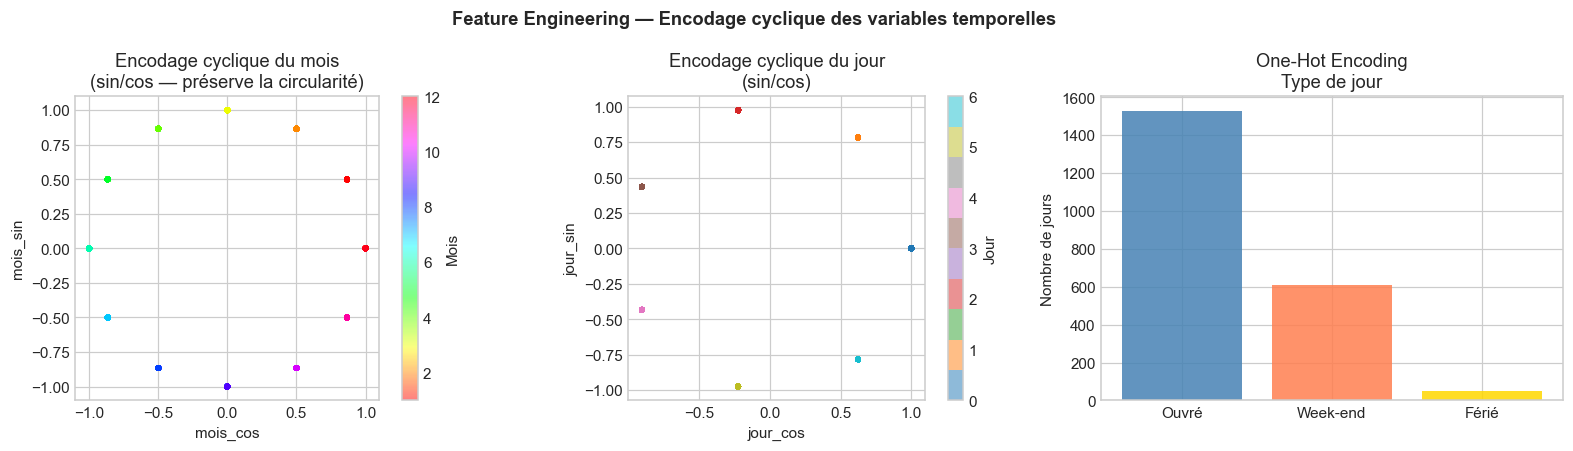

In [5]:
# Visualisation de l'encodage cyclique du mois
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Engineering — Encodage cyclique des variables temporelles', fontweight='bold')

ax1 = axes[0]
scatter = ax1.scatter(df_feat['mois_cos'], df_feat['mois_sin'],
                      c=df_feat['mois'], cmap='hsv', s=8, alpha=0.5)
plt.colorbar(scatter, ax=ax1, label='Mois')
ax1.set_title('Encodage cyclique du mois\n(sin/cos — préserve la circularité)')
ax1.set_xlabel('mois_cos'); ax1.set_ylabel('mois_sin')
ax1.set_aspect('equal')

ax2 = axes[1]
scatter2 = ax2.scatter(df_feat['jour_cos'], df_feat['jour_sin'],
                       c=df_feat['jour_semaine'], cmap='tab10', s=8, alpha=0.5)
plt.colorbar(scatter2, ax=ax2, label='Jour')
ax2.set_title('Encodage cyclique du jour\n(sin/cos)')
ax2.set_xlabel('jour_cos'); ax2.set_ylabel('jour_sin')
ax2.set_aspect('equal')

ax3 = axes[2]
type_counts = df_feat[['est_ouvre', 'est_weekend', 'est_ferie']].sum()
ax3.bar(['Ouvré', 'Week-end', 'Férié'], type_counts.values,
        color=['steelblue', 'coral', 'gold'], alpha=0.85)
ax3.set_title('One-Hot Encoding\nType de jour')
ax3.set_ylabel('Nombre de jours')

plt.tight_layout()
plt.savefig(PROCESSED_PATH / '05_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Split temporel Train / Test

In [6]:
feature_cols = get_feature_columns()
X_train, X_test, y_train, y_test = split_train_test(df_feat, feature_cols, test_size=0.20)

# Récupérer les dates correspondantes pour la visualisation
split_idx = int(len(df_feat) * 0.80)
dates_train = df_feat['date'].values[:split_idx]
dates_test  = df_feat['date'].values[split_idx:]

print(f'Train : {len(X_train)} jours ({pd.Timestamp(dates_train[0]).date()} → {pd.Timestamp(dates_train[-1]).date()})')
print(f'Test  : {len(X_test)} jours ({pd.Timestamp(dates_test[0]).date()} → {pd.Timestamp(dates_test[-1]).date()})')
print(f'Ratio test : {len(X_test)/len(df_feat)*100:.1f}%')
print(f'\nNombre de features : {X_train.shape[1]}')
print(f'Features : {feature_cols}')

Train : 1748 jours (2019-01-08 → 2023-10-21)
Test  : 437 jours (2023-10-22 → 2024-12-31)
Ratio test : 20.0%

Nombre de features : 14
Features : ['consommation_j1', 'consommation_j7', 'consommation_ma7', 'temperature_moyenne', 'temperature_min', 'temperature_max', 'mois_sin', 'mois_cos', 'jour_sin', 'jour_cos', 'est_ouvre', 'est_weekend', 'est_ferie', 'est_hiver']


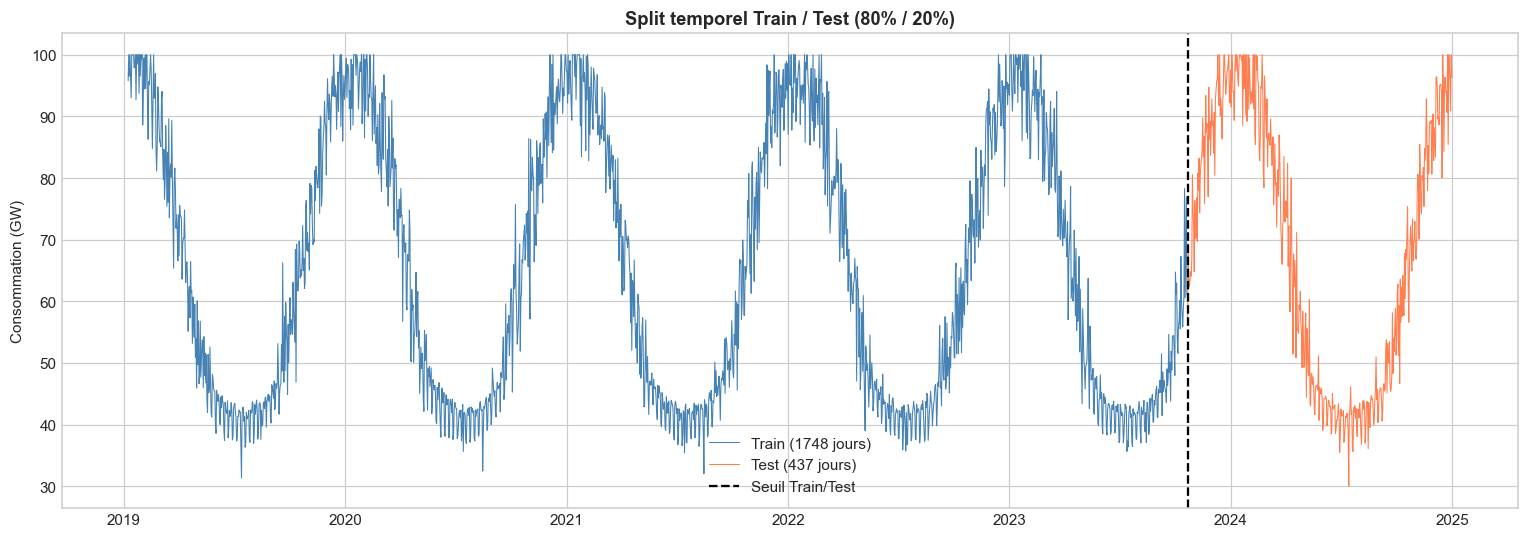

In [7]:
# Visualisation du split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_train, y_train / 1000, linewidth=0.7, color='steelblue', label=f'Train ({len(y_train)} jours)')
ax.plot(dates_test, y_test / 1000, linewidth=0.7, color='coral', label=f'Test ({len(y_test)} jours)')
ax.axvline(dates_test[0], color='black', linestyle='--', linewidth=1.5, label='Seuil Train/Test')
ax.set_ylabel('Consommation (GW)')
ax.set_title('Split temporel Train / Test (80% / 20%)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_PATH / '06_split_train_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Normalisation (StandardScaler)

In [10]:
scaler_path = str(PROCESSED_PATH / 'scaler.pkl')
X_train_sc, X_test_sc, scaler = normalize_features(X_train, X_test, scaler_path=scaler_path)

print('Avant normalisation (X_train) :')
print(f'  Moyenne : {X_train.mean(axis=0).round(2)}')
print(f'  Écart-type : {X_train.std(axis=0).round(2)}')

print('\nAprès normalisation (X_train_sc) :')
print(f'  Moyenne : {X_train_sc.mean(axis=0).round(3)} (≈ 0)')
print(f'  Écart-type : {X_train_sc.std(axis=0).round(3)} (≈ 1)')

print(f'\n Scaler sauvegardé → {scaler_path}')

Avant normalisation (X_train) :
  Moyenne : [ 6.490529e+04  6.499870e+04  6.494833e+04  1.238000e+01  9.400000e+00
  1.637000e+01  1.000000e-02 -4.000000e-02  0.000000e+00 -0.000000e+00
  7.000000e-01  2.800000e-01  2.000000e-02  3.900000e-01]
  Écart-type : [2.141106e+04 2.147674e+04 2.104051e+04 7.350000e+00 7.370000e+00
 7.410000e+00 7.100000e-01 7.000000e-01 7.100000e-01 7.100000e-01
 4.600000e-01 4.500000e-01 1.400000e-01 4.900000e-01]

Après normalisation (X_train_sc) :
  Moyenne : [ 0.  0.  0.  0.  0. -0.  0.  0.  0. -0. -0. -0. -0. -0.] (≈ 0)
  Écart-type : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] (≈ 1)

 Scaler sauvegardé → ..\data\processed\scaler.pkl


## 5. Sauvegarde des datasets

In [11]:
np.save(PROCESSED_PATH / 'X_train.npy', X_train_sc)
np.save(PROCESSED_PATH / 'X_test.npy', X_test_sc)
np.save(PROCESSED_PATH / 'y_train.npy', y_train)
np.save(PROCESSED_PATH / 'y_test.npy', y_test)
df_feat.to_parquet(PROCESSED_PATH / 'dataset_processed.parquet', index=False)
pd.Series(feature_cols).to_csv(PROCESSED_PATH / 'feature_cols.csv', index=False)

print(' Datasets sauvegardés dans data/processed/ :')
print(f'   X_train.npy   : {X_train_sc.shape}')
print(f'   X_test.npy    : {X_test_sc.shape}')
print(f'   y_train.npy   : {y_train.shape}')
print(f'   y_test.npy    : {y_test.shape}')
print(f'   scaler.pkl    : StandardScaler entraîné')
print(f'   dataset_processed.parquet : {df_feat.shape}')
print('\n Prétraitement terminé — Prêt pour les notebooks modèles (03-06)')

 Datasets sauvegardés dans data/processed/ :
   X_train.npy   : (1748, 14)
   X_test.npy    : (437, 14)
   y_train.npy   : (1748,)
   y_test.npy    : (437,)
   scaler.pkl    : StandardScaler entraîné
   dataset_processed.parquet : (2185, 21)

 Prétraitement terminé — Prêt pour les notebooks modèles (03-06)
